# Student Score Predictor Model

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


### Importing the Student_Performance.csv data


In [2]:
df = pd.read_csv("Student_Performance.csv")

### Analyzing the Data

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [6]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [7]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [8]:
print(df["Extracurricular Activities"].unique())

['Yes' 'No']


### Data Preprocessing
#### Fixing the DataType of Extracurricular Activities column


In [9]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes" : 1,
    "No" : 0
})

In [10]:
print(df["Extracurricular Activities"].unique())

[1 0]


### Seperating the X(Input) and Y(Output) Variables

In [20]:
X = df.drop(["Performance Index"],axis=1)
Y = df["Performance Index"]

In [21]:
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [13]:
Y.head()

0    91
1    65
2    45
3    36
4    66
Name: Performance Index, dtype: int64

In [15]:
X.shape

(10000, 5)

In [22]:
Y.shape

(10000,)

### Train-Test Split

In [26]:
X = X.to_numpy()
Y = Y.to_numpy()

In [27]:
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
Y = Y[indices]

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

### Feature Scaling

In [39]:
#Feature Scaling
mean = np.mean(X_train,axis=0)
std = np.std(X_train,axis=0)
X_train = (X_train - mean)/std
X_test = (X_test - mean)/std

### Training the Model

In [42]:
w = np.random.randn(X_train.shape[1])
b = 0
loss_history = []
epochs = 1000
n = len(X_train)
alpha = 0.01
for i in range(epochs):
    #Compute the prediction
    y_pred = np.dot(X_train,w) + b
    #Find loss
    error = y_pred - Y_train
    loss = np.mean(error**2)
    #Compute Derivatives
    dw = (2/n) * (np.dot(X_train.T,error))
    db = (2/n) * (np.sum(error))
    #Update Parameters
    w = w - alpha*dw
    b = b - alpha*db
    loss_history.append(loss)
    if i%100 == 0:
        print(f"Epoch {i+1} :- Loss : {loss:.4f}")
print("w =", w)

Epoch 1 :- Loss : 3411.6608
Epoch 101 :- Loss : 64.3320
Epoch 201 :- Loss : 5.2085
Epoch 301 :- Loss : 4.1630
Epoch 401 :- Loss : 4.1445
Epoch 501 :- Loss : 4.1442
Epoch 601 :- Loss : 4.1442
Epoch 701 :- Loss : 4.1442
Epoch 801 :- Loss : 4.1442
Epoch 901 :- Loss : 4.1442
w = [ 7.38118616 17.6587385   0.30754433  0.81238728  0.57690187]


In [44]:
y_pred_test = np.dot(X_test,w)+b
print(y_pred_test)

[63.20171095 78.07804215 20.96415166 ... 44.99595984 20.91541258
 22.52110038]


In [45]:
test_loss = np.mean((y_pred_test - Y_test)**2)

print("Test Loss:", test_loss)

Test Loss: 4.183573001631033


### Loss Graph


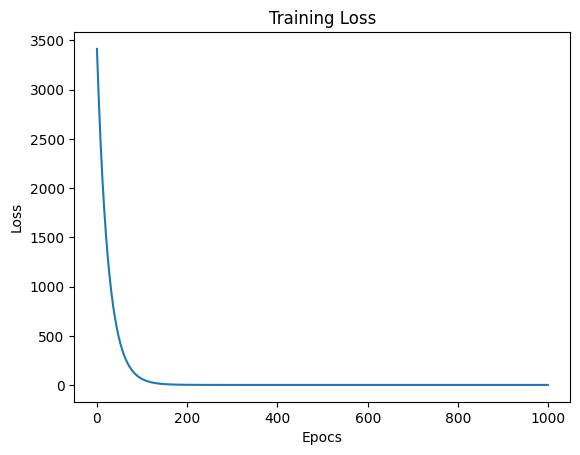

In [48]:
plt.plot(loss_history)
plt.xlabel("Epocs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

### Scattter Plot for actual and predicted Values

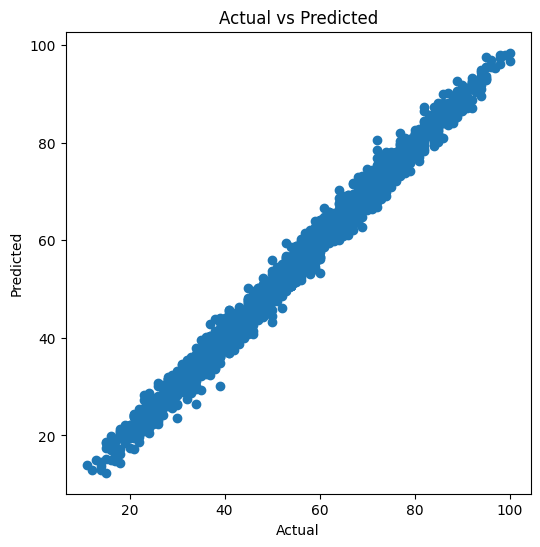

In [49]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred_test)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

### Testing the Model by a sample taken from the data

In [51]:
student = np.array([7, 99, 1, 9, 1])
student = (student - mean)/std
predicted_Score = np.dot(student,w) + b
print("Predicted Score : ",predicted_Score)

Predicted Score :  91.80980297869273


### This model takes 5 features Hours Studied, Previous Score, Extracurricular Activities, Hours Slept, Practice test and then it predict how much marks the student can get on the upcoming exam.